# Travel Reimbursement Approval Agent

Runnable prototype that reviews the five Appendix B claims against the Appendix A policy and returns a structured recommendation for each claim.

## README

### Setup

From the project root, with Python 3.11:

```bash
python -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
jupyter notebook akshay_solanki.ipynb
```

### Environment variables

Create a `.env` file in the project root. The notebook calls `load_dotenv()` and does not hard-code a key.

```text
OPENAI_API_KEY=
```

`OPENAI_BASE_URL` is not required. `ChatOpenAI` uses the standard OpenAI endpoint.

### How to run

Run this notebook from top to bottom. All of the models, policy, sample claims, tools, agent, and dashboard live in this notebook.

Each claim is one agent run. It calls the OpenAI API, then prints the tool trace. If the API call fails, that claim still gets a structured result from the same policy tools.

### Design choices

- The agent uses `load_dotenv()`, `ChatOpenAI`, `@tool`, `create_agent`, and a printed execution trace.
- Policy math lives in four tools: policy lookup, receipt check, category limits, and timeliness plus approval threshold.
- A validator compares the model JSON with those tool results and keeps the tool decision when the model contradicts the policy.
- The dashboard is drawn from the actual result objects, not from hand-entered totals.


## Design Notes & Reasoning

### Assumptions

- The expense date for the 30-day window is the trip end date.
- Day and night counts come from the line item. The description is the fallback, then the trip length.
- The meal cap is 75 USD per employee per day. Appendix A has no guest or client-entertainment exception, so a dinner for four is still one meal day.
- Economy is the default airfare class unless the line says business or first class.
- Conference fees have no dollar cap. They still need a receipt when the line is over 25 USD.
- An ineligible line is deducted in full even when a receipt is attached.

### How a decision is chosen

- **APPROVE** when every line is eligible, required receipts are present, nothing exceeds a cap, and the reimbursable total is at or under 2,000 USD.
- **PARTIAL APPROVE** when the only problem is spend above a per-diem cap. The amount up to the cap is reimbursed and the excess is deducted.
- **REJECT** when every line is ineligible and nothing is left to reimburse.
- **MANUAL REVIEW** when a required receipt is missing, airfare is business or first class, the reimbursable total is over 2,000 USD, the claim is late, or the category is not in the policy. Manual review wins over partial approval.

Business and first class fares are not auto-deducted, because a pre-approval may exist. A missing receipt does not silently reject the line. Cap excess is still deducted, because that portion is not reimbursable even if a reviewer later accepts the rest.

When manual review is claim-level (late submission or total over 2,000 USD), `approved_amount` is 0. The pending dollars are described in the explanation rather than treated as approved.

### Why these claims go to manual review

- **CLM-004** has business-class airfare (`POL-AIR-01`), a lodging line with no receipt (`POL-RCT-01`, `POL-RCT-02`), and a 3,000 USD reimbursable total (`POL-APR-03`).
- **CLM-005** is a 220 USD meal with no receipt, and it is 145 USD over the 75 USD daily cap. The missing receipt blocks partial approval of the 75 USD that is inside the cap.

### Trade-offs

The model chooses tools and writes the explanation. The tools own the amounts. That keeps a wrong model total from approving an over-cap line, at the cost of the model not being the only source of the final numbers. Temperature is 0.2 so repeated runs stay stable. The prototype uses one agent instead of a multi-agent review board, which is enough for five claims and easier to trace.

### What I would improve next

- A reviewer queue that records who cleared a manual-review claim and the receipt they attached.
- Duplicate detection across claim ids.
- Receipt image extraction, instead of a boolean `receipt_attached` flag.
- An explicit client-entertainment rule if dinners for several guests should exceed the 75 USD cap.

### Known gaps

- No real employee data and no live finance system. The five claims are the assignment samples.
- Currency is USD only.
- The agent needs a funded `OPENAI_API_KEY`. The policy tools still return a schema-valid result when that call fails.


In [1]:
import json
import re
from datetime import date
from enum import Enum
from pathlib import Path

from dotenv import load_dotenv
from openai import api_key
from pydantic import BaseModel, Field, model_validator

from langchain.tools import tool
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI


class Decision(str, Enum):
    """Allowed reimbursement decisions from the assignment."""

    APPROVE = "APPROVE"
    PARTIAL_APPROVE = "PARTIAL_APPROVE"
    REJECT = "REJECT"
    MANUAL_REVIEW = "MANUAL_REVIEW"


class LineItem(BaseModel):
    """One expense line on a reimbursement claim."""

    category: str
    description: str
    amount: float = Field(ge=0)
    receipt_attached: bool
    units: int | None = Field(default=None, ge=1)
    travel_class: str | None = None


class Claim(BaseModel):
    """Employee travel claim accepted from JSON."""

    claim_id: str
    employee: str
    purpose: str
    trip_start: date
    trip_end: date
    submitted_date: date
    line_items: list[LineItem]
    total_claimed: float = 0

    @model_validator(mode="after")
    def fill_total(self) -> "Claim":
        """Set the claim total from its line items so callers cannot drift from the lines."""
        self.total_claimed = round(sum(item.amount for item in self.line_items), 2)
        return self


class ClaimEvaluationResult(BaseModel):
    """Structured recommendation required for every claim."""

    claim_id: str
    decision: Decision
    approved_amount: float = Field(ge=0)
    deducted_amount: float = Field(ge=0)
    missing_docs: list[str] = Field(default_factory=list)
    policy_refs: list[str] = Field(default_factory=list)
    confidence: float = Field(ge=0, le=1)
    explanation: str
    tools_used: list[str] = Field(default_factory=list)

POLICIES: dict[str, str] = {
    "POL-CAT-01": (
        "Eligible categories, reimbursable for a documented business purpose: "
        "economy airfare, lodging, meals, ground transport, and conference or registration fees."
    ),
    "POL-CAT-02": (
        "Ineligible items are never reimbursable and are deducted in full: alcohol, minibar, "
        "spa, gym, personal entertainment, in-room movies, personal shopping, gifts, traffic "
        "fines, penalties, late fees, and any personal non-business expense."
    ),
    "POL-PD-01": "Meals are capped at $75 per day. Amounts above the daily cap are deducted.",
    "POL-PD-02": "Lodging is capped at $200 per night. Amounts above the nightly cap are deducted.",
    "POL-PD-03": "Ground transport is capped at $50 per day. Amounts above the cap are deducted.",
    "POL-AIR-01": (
        "Only economy airfare is reimbursable. Business or first class is a policy exception "
        "and must be routed to manual review. Do not auto-deduct that fare."
    ),
    "POL-RCT-01": (
        "Any single line item over $25 needs an itemized receipt. Airfare and lodging always "
        "need a receipt, regardless of amount."
    ),
    "POL-RCT-02": (
        "A missing receipt for an item that requires one does not silently reject the item. "
        "Route the claim to manual review so a reviewer can request the receipt."
    ),
    "POL-APR-01": "Reimbursable total at or under $500 may be auto-approved when fully compliant.",
    "POL-APR-02": (
        "Reimbursable total above $500 and at or under $2,000 may be approved when fully compliant."
    ),
    "POL-APR-03": (
        "Reimbursable total above $2,000 exceeds the agent's authority and must go to manual "
        "review for director approval, even when otherwise compliant."
    ),
    "POL-TIME-01": (
        "Claims must be submitted within 30 days of the expense date. Late claims go to manual review."
    ),
}

POLICY_ORDER: list[str] = list(POLICIES)

ELIGIBLE_CATEGORIES = {
    "airfare",
    "lodging",
    "meals",
    "ground_transport",
    "conference_fees",
}

INELIGIBLE_CATEGORIES = {
    "spa",
    "gym",
    "minibar",
    "alcohol",
    "entertainment",
    "movies",
    "shopping",
    "gifts",
    "fines",
    "penalties",
    "personal",
}

INELIGIBLE_KEYWORDS = (
    "alcohol",
    "minibar",
    "spa",
    "gym",
    "entertainment",
    "movie",
    "shopping",
    "gift",
    "traffic fine",
    "penalty",
    "late fee",
    "personal",
)

CATEGORY_ALIASES = {
    "air": "airfare",
    "airfare": "airfare",
    "flight": "airfare",
    "hotel": "lodging",
    "lodging": "lodging",
    "meal": "meals",
    "meals": "meals",
    "taxi": "ground_transport",
    "rideshare": "ground_transport",
    "train": "ground_transport",
    "parking": "ground_transport",
    "rental_car": "ground_transport",
    "ground_transport": "ground_transport",
    "ground": "ground_transport",
    "conference": "conference_fees",
    "registration": "conference_fees",
    "conference_fees": "conference_fees",
}

CATEGORY_CAPS = {
    "meals": (75.0, "day", "POL-PD-01"),
    "lodging": (200.0, "night", "POL-PD-02"),
    "ground_transport": (50.0, "day", "POL-PD-03"),
}

RECEIPT_THRESHOLD = 25.0
AUTO_APPROVE_LIMIT = 500.0
DIRECTOR_LIMIT = 2000.0
SUBMISSION_WINDOW_DAYS = 30
ALWAYS_REQUIRE_RECEIPT = {"airfare", "lodging"}


def ordered_refs(refs):
    seen = set(refs)
    return [pid for pid in POLICY_ORDER if pid in seen]

def _claim(
    claim_id: str,
    employee: str,
    purpose: str,
    trip_start: str,
    trip_end: str,
    submitted_date: str,
    items: list[LineItem],
) -> Claim:
    """Build one sample claim from the dates and lines in Appendix B."""
    return Claim(
        claim_id=claim_id,
        employee=employee,
        purpose=purpose,
        trip_start=trip_start,
        trip_end=trip_end,
        submitted_date=submitted_date,
        line_items=items,
    )


SAMPLE_CLAIMS: list[Claim] = [
    _claim(
        "CLM-001",
        "A. Rivera",
        "Attend 2-day industry conference (business)",
        "2026-06-10",
        "2026-06-12",
        "2026-06-20",
        [
            LineItem(
                category="airfare",
                description="Round-trip economy airfare",
                amount=420.00,
                receipt_attached=True,
                travel_class="economy",
            ),
            LineItem(
                category="lodging",
                description="Hotel, 2 nights @ $180",
                amount=360.00,
                receipt_attached=True,
                units=2,
            ),
            LineItem(
                category="meals",
                description="Meals, 3 days @ ~$60/day",
                amount=180.00,
                receipt_attached=True,
                units=3,
            ),
            LineItem(
                category="conference_fees",
                description="Conference registration",
                amount=150.00,
                receipt_attached=True,
            ),
        ],
    ),
    _claim(
        "CLM-002",
        "B. Osei",
        "Weekend hotel stay",
        "2026-06-14",
        "2026-06-15",
        "2026-06-25",
        [
            LineItem(
                category="spa",
                description="Hotel spa package",
                amount=300.00,
                receipt_attached=True,
            ),
            LineItem(
                category="minibar",
                description="In-room minibar",
                amount=80.00,
                receipt_attached=True,
            ),
        ],
    ),
    _claim(
        "CLM-003",
        "C. Nakamura",
        "Client site visit (business)",
        "2026-06-08",
        "2026-06-10",
        "2026-06-22",
        [
            LineItem(
                category="airfare",
                description="Round-trip economy airfare",
                amount=300.00,
                receipt_attached=True,
                travel_class="economy",
            ),
            LineItem(
                category="lodging",
                description="Hotel, 2 nights @ $250",
                amount=500.00,
                receipt_attached=True,
                units=2,
            ),
            LineItem(
                category="meals",
                description="Meals, 2 days @ $70/day",
                amount=140.00,
                receipt_attached=True,
                units=2,
            ),
        ],
    ),
    _claim(
        "CLM-004",
        "D. Fischer",
        "International vendor negotiation (business)",
        "2026-06-16",
        "2026-06-18",
        "2026-06-28",
        [
            LineItem(
                category="airfare",
                description="Business-class international airfare",
                amount=2400.00,
                receipt_attached=True,
                travel_class="business",
            ),
            LineItem(
                category="lodging",
                description="Hotel, 3 nights",
                amount=600.00,
                receipt_attached=False,
                units=3,
            ),
        ],
    ),
    _claim(
        "CLM-005",
        "E. Haddad",
        "Client dinner / business development",
        "2026-06-11",
        "2026-06-11",
        "2026-06-24",
        [
            LineItem(
                category="meals",
                description="Client dinner for 4 (business development)",
                amount=220.00,
                receipt_attached=False,
                units=1,
            ),
        ],
    ),
]


def load_sample_claims() -> list[Claim]:
    """Return the five Appendix B claims."""
    return list(SAMPLE_CLAIMS)


def get_sample_claim(claim_id: str) -> Claim:
    """Return one sample claim by id."""
    for claim in SAMPLE_CLAIMS:
        if claim.claim_id == claim_id:
            return claim
    known = ", ".join(claim.claim_id for claim in SAMPLE_CLAIMS)
    raise KeyError(f"Unknown claim_id {claim_id}. Known claims: {known}")


TOOL_NAMES = [
    "policy_lookup",
    "check_receipt_compliance",
    "calculate_category_limits",
    "check_timeliness_and_approval_threshold",
]


def money(val):
    return round(float(val), 2)


def canonical_category(raw):
    key = raw.strip().lower().replace("/", " ").replace("-", " ")
    key = "_".join(key.split())
    return CATEGORY_ALIASES.get(key, key)


def is_ineligible(category, description):
    if category in INELIGIBLE_CATEGORIES:
        return True
    text = f"{category} {description}".lower()
    return any(k in text for k in INELIGIBLE_KEYWORDS)


def resolve_units(item, claim, category):
    if item.units:
        return item.units
    match = re.search(r"(\d+)\s*(night|nights|day|days)", item.description.lower())
    if match:
        return int(match.group(1))
    nights = (claim.trip_end - claim.trip_start).days
    if category == "lodging":
        return max(nights, 1)
    return max(nights + 1, 1)


def resolve_travel_class(item):
    if item.travel_class:
        return item.travel_class.strip().lower()
    text = item.description.lower()
    if "first" in text:
        return "first"
    if "business" in text:
        return "business"
    return "economy"


def receipt_required(category, amount):
    return category in ALWAYS_REQUIRE_RECEIPT or amount > RECEIPT_THRESHOLD


def analyze_line(item, claim):
    category = canonical_category(item.category)
    claimed = money(item.amount)

    finding = {
        "description": item.description,
        "category": category,
        "claimed": claimed,
        "approved": 0.0,
        "deducted": 0.0,
        "pending": 0.0,
        "policy_refs": [],
        "notes": [],
        "missing_doc": None,
        "needs_manual_review": False,
    }

    if is_ineligible(category, item.description):
        finding["deducted"] = claimed
        finding["policy_refs"].append("POL-CAT-02")
        finding["notes"].append(f"{item.description} (${claimed:.2f}) is an ineligible personal expense.")
        return finding

    if category not in ELIGIBLE_CATEGORIES:
        finding["pending"] = claimed
        finding["needs_manual_review"] = True
        finding["notes"].append(f"Category '{item.category}' is not listed in policy.")
        return finding

    finding["policy_refs"].append("POL-CAT-01")

    if category == "airfare":
        tclass = resolve_travel_class(item)
        if tclass in ("business", "first"):
            finding["pending"] = claimed
            finding["needs_manual_review"] = True
            finding["policy_refs"].append("POL-AIR-01")
            finding["notes"].append(f"{item.description} is {tclass}-class (requires pre-approval review).")
        else:
            finding["approved"] = claimed
            finding["policy_refs"].append("POL-AIR-01")
            finding["notes"].append(f"{item.description} is economy airfare.")
    elif category in CATEGORY_CAPS:
        cap, unit, pol_id = CATEGORY_CAPS[category]
        units = resolve_units(item, claim, category)
        cap_total = money(cap * units)
        finding["policy_refs"].append(pol_id)

        if claimed > cap_total:
            finding["deducted"] = money(claimed - cap_total)
            finding["approved"] = cap_total
            finding["notes"].append(
                f"{item.description}: ${claimed:.2f} exceeds {units} {unit} cap of ${cap_total:.2f}. "
                f"${finding['deducted']:.2f} deducted."
            )
        else:
            finding["approved"] = claimed
            finding["notes"].append(f"{item.description} is within ${cap}/{unit} cap.")
    else:
        finding["approved"] = claimed
        finding["notes"].append(f"{item.description} is eligible.")

    if receipt_required(category, claimed):
        finding["policy_refs"].append("POL-RCT-01")
        if not item.receipt_attached:
            finding["pending"] = money(finding["pending"] + finding["approved"])
            finding["approved"] = 0.0
            finding["needs_manual_review"] = True
            finding["policy_refs"].append("POL-RCT-02")
            finding["missing_doc"] = f"{category}: {item.description} requires an itemized receipt"
            finding["notes"].append(f"{item.description} is missing a required receipt.")

    return finding


def analyze_claim(claim):
    lines = [analyze_line(item, claim) for item in claim.line_items]
    approved = money(sum(l["approved"] for l in lines))
    pending = money(sum(l["pending"] for l in lines))
    reimbursable = money(approved + pending)

    days_after = (claim.submitted_date - claim.trip_end).days
    on_time = days_after <= SUBMISSION_WINDOW_DAYS

    reasons = []
    claim_level_manual = False

    if not on_time:
        claim_level_manual = True
        reasons.append(f"Submitted {days_after} days after trip end (window is {SUBMISSION_WINDOW_DAYS} days).")

    approval_policy = None
    if reimbursable > DIRECTOR_LIMIT:
        approval_policy = "POL-APR-03"
        claim_level_manual = True
        reasons.append(f"Reimbursable total ${reimbursable:.2f} exceeds $2000 (Director approval required).")
    elif reimbursable > AUTO_APPROVE_LIMIT:
        approval_policy = "POL-APR-02"
        reasons.append(f"Reimbursable total ${reimbursable:.2f} is in manager approval tier.")
    elif reimbursable > 0:
        approval_policy = "POL-APR-01"
        reasons.append(f"Reimbursable total ${reimbursable:.2f} is in auto-approve tier.")
    else:
        reasons.append("Nothing reimbursable remains.")

    return {
        "lines": lines,
        "days_after_expense": days_after,
        "submitted_on_time": on_time,
        "reimbursable_total": reimbursable,
        "approval_policy": approval_policy,
        "claim_level_manual": claim_level_manual,
        "claim_level_reasons": reasons,
    }


def combine_facts(claim, facts, tools_used):
    lines = facts["lines"]
    approved = money(sum(l["approved"] for l in lines))
    deducted = money(sum(l["deducted"] for l in lines))
    pending = money(sum(l["pending"] for l in lines))
    line_manual = any(l["needs_manual_review"] for l in lines)

    if facts["claim_level_manual"]:
        pending = money(pending + approved)
        approved = 0.0

    if approved == 0 and pending == 0 and deducted > 0 and not line_manual and not facts["claim_level_manual"]:
        decision = Decision.REJECT
        confidence = 0.95
    elif line_manual or facts["claim_level_manual"] or pending > 0:
        decision = Decision.MANUAL_REVIEW
        confidence = 0.70
    elif deducted > 0:
        decision = Decision.PARTIAL_APPROVE
        confidence = 0.90
    else:
        decision = Decision.APPROVE
        confidence = 0.95

    refs = []
    missing_docs = []
    notes = []
    for l in lines:
        refs.extend(l["policy_refs"])
        notes.extend(l["notes"])
        if l["missing_doc"]:
            missing_docs.append(l["missing_doc"])

    if not facts["submitted_on_time"]:
        refs.append("POL-TIME-01")
    if facts["approval_policy"]:
        refs.append(facts["approval_policy"])
    notes.extend(facts["claim_level_reasons"])

    if decision == Decision.MANUAL_REVIEW and pending > 0:
        notes.append(f"${pending:.2f} held pending manual review.")

    return ClaimEvaluationResult(
        claim_id=claim.claim_id,
        decision=decision,
        approved_amount=approved,
        deducted_amount=deducted,
        missing_docs=missing_docs,
        policy_refs=ordered_refs(refs),
        confidence=confidence,
        explanation=" ".join(notes),
        tools_used=list(tools_used),
    )


def parse_claim_input(raw):
    text = raw.strip()
    if text.upper().startswith("CLM-") and not text.startswith("{"):
        return get_sample_claim(text.split()[0].upper())
    data = json.loads(text)
    if isinstance(data, dict) and "line_items" not in data and "claim_id" in data:
        return get_sample_claim(str(data["claim_id"]))
    return Claim.model_validate(data)


def build_recommendation(claim, tools_used=None):
    facts = analyze_claim(claim)
    return combine_facts(claim, facts, tools_used or TOOL_NAMES)


@tool
def policy_lookup(policy_id: str) -> str:
    """Look up a travel reimbursement rule by id (e.g. POL-PD-01) or 'ALL' to list every rule."""
    key = policy_id.strip().upper()
    if key == "ALL":
        return json.dumps({"policies": [{"id": pid, "text": txt} for pid, txt in POLICIES.items()]})
    if key not in POLICIES:
        return json.dumps({"error": f"Unknown policy id {policy_id}", "valid_ids": list(POLICIES.keys())})
    return json.dumps({"id": key, "text": POLICIES[key]})


@tool
def check_receipt_compliance(claim_json: str) -> str:
    """Check line items for missing receipts according to policy rules."""
    try:
        claim = parse_claim_input(claim_json)
    except Exception as e:
        return json.dumps({"error": f"Invalid claim: {e}"})

    facts = analyze_claim(claim)
    missing = [l["missing_doc"] for l in facts["lines"] if l["missing_doc"]]
    refs = ordered_refs([r for l in facts["lines"] for r in l["policy_refs"] if r.startswith("POL-RCT")])
    return json.dumps({
        "claim_id": claim.claim_id,
        "missing_docs": missing,
        "has_missing_receipts": bool(missing),
        "policy_refs": refs,
    })


@tool
def calculate_category_limits(claim_json: str) -> str:
    """Check eligible categories, calculate per-diem caps and overages, and check travel class."""
    try:
        claim = parse_claim_input(claim_json)
    except Exception as e:
        return json.dumps({"error": f"Invalid claim: {e}"})

    facts = analyze_claim(claim)
    return json.dumps({
        "claim_id": claim.claim_id,
        "lines": facts["lines"],
        "total_approved": money(sum(l["approved"] for l in facts["lines"])),
        "total_deducted": money(sum(l["deducted"] for l in facts["lines"])),
        "total_pending": money(sum(l["pending"] for l in facts["lines"])),
    })


@tool
def check_timeliness_and_approval_threshold(claim_json: str) -> str:
    """Check 30-day submission timeliness and approval authority threshold."""
    try:
        claim = parse_claim_input(claim_json)
    except Exception as e:
        return json.dumps({"error": f"Invalid claim: {e}"})

    facts = analyze_claim(claim)
    return json.dumps({
        "claim_id": claim.claim_id,
        "submitted_on_time": facts["submitted_on_time"],
        "days_after_expense": facts["days_after_expense"],
        "reimbursable_total": facts["reimbursable_total"],
        "approval_policy": facts["approval_policy"],
        "claim_level_manual": facts["claim_level_manual"],
        "reasons": facts["claim_level_reasons"],
    })


AGENT_TOOLS = [
    policy_lookup,
    check_receipt_compliance,
    calculate_category_limits,
    check_timeliness_and_approval_threshold,
]


SYSTEM_PROMPT = """
# ROLE
You are a travel reimbursement approval agent. You apply only the company policy returned by the tools.

# OBJECTIVE
Evaluate one claim and choose APPROVE, PARTIAL_APPROVE, REJECT, or MANUAL_REVIEW.

# AVAILABLE TOOLS
- policy_lookup: read POL-* rules. Call it with policy_id ALL.
- check_receipt_compliance: find missing required receipts.
- calculate_category_limits: apply eligibility, per-diem caps, and airfare class.
- check_timeliness_and_approval_threshold: apply the 30-day window and the approval tier.

# INSTRUCTIONS
1. Call all four tools before deciding. Pass the claim JSON string to every tool except policy_lookup.
2. Use the tool results for amounts, missing documents, and policy ids.
3. APPROVE only when every line is eligible, receipts are present, amounts are within caps, and the reimbursable total is at or under $2,000.
4. PARTIAL_APPROVE when the only problem is an amount above a per-diem cap. Reimburse up to the cap and deduct the excess.
5. REJECT when every claimed item is ineligible and nothing can be reimbursed.
6. MANUAL_REVIEW for a missing required receipt, business or first-class airfare, a reimbursable total above $2,000, a late submission, or any category the policy does not list.
7. Do not auto-deduct business or first-class airfare. Do not approve a line that is missing a required receipt.
8. If a claim-level manual review rule applies, set approved_amount to 0. Deduct only amounts the tools mark as deducted.

# CONSTRAINTS
- Do not invent policy limits, receipts, or amounts.
- Do not claim that you used a tool if you did not use it.
- Prefer MANUAL_REVIEW over forcing a decision when the tools disagree or information is missing.

# OUTPUT FORMAT
Return one JSON object and no other text. Use exactly these fields:
claim_id, decision, approved_amount, deducted_amount, missing_docs, policy_refs, confidence, explanation, tools_used.
decision must be APPROVE, PARTIAL_APPROVE, REJECT, or MANUAL_REVIEW.
"""

def get_agent():
    load_dotenv()
    llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.2, api_key="sk-proj-mykey")
    return create_agent(model=llm, tools=AGENT_TOOLS, system_prompt=SYSTEM_PROMPT)


def claim_prompt(claim):
    payload = claim.model_dump_json()
    return f"Evaluate this travel reimbursement claim.\n\nCLAIM_JSON:\n{payload}"


def message_text(message):
    content = message.content
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts = []
        for block in content:
            if isinstance(block, str):
                parts.append(block)
            elif isinstance(block, dict):
                parts.append(str(block.get("text", "")))
        return "\n".join(parts)
    return str(content)


def print_trace(messages):
    print("\n" + "=" * 60)
    print("AGENT EXECUTION TRACE")
    print("=" * 60)
    tools_used = []
    for message in messages:
        print("\nMESSAGE CLASS:", type(message))
        print("MESSAGE TYPE:", message.type)
        print("CONTENT:", message_text(message))
        if hasattr(message, "tool_calls") and message.tool_calls:
            print("TOOL CALLS:", message.tool_calls)
            for tool_call in message.tool_calls:
                name = tool_call["name"]
                print("\n AGENT DECISION")
                print(f"Tool selected: {name}")
                print(f"Input: {tool_call['args']}")
                if name in TOOL_NAMES and name not in tools_used:
                    tools_used.append(name)
        if message.type == "tool":
            print("\n TOOL EXECUTED")
            print(f"Tool: {message.name}")
            print(f"Output: {message_text(message)}")
            if message.name in TOOL_NAMES and message.name not in tools_used:
                tools_used.append(message.name)
    print("\n" + "=" * 60)
    return tools_used


def parse_model_result(text, claim_id):
    fenced = re.search(r"```(?:json)?\s*(\{.*\})\s*```", text, re.DOTALL)
    raw = fenced.group(1) if fenced else text
    start = raw.find("{")
    end = raw.rfind("}")
    if start < 0 or end < start:
        return None
    try:
        data = json.loads(raw[start : end + 1])
    except Exception:
        return None
    data["claim_id"] = data.get("claim_id") or claim_id
    try:
        return ClaimEvaluationResult.model_validate(data)
    except Exception:
        return None


def reconcile(parsed, baseline, tools_used):
    final = baseline.model_copy(deep=True)
    final.tools_used = tools_used or baseline.tools_used
    if parsed is None:
        print("Note: Agent output could not be parsed as json, using tool calculations.")
        return final

    amounts_match = (
        parsed.decision == baseline.decision
        and abs(parsed.approved_amount - baseline.approved_amount) < 0.01
        and abs(parsed.deducted_amount - baseline.deducted_amount) < 0.01
    )
    if amounts_match and parsed.explanation.strip():
        final.explanation = parsed.explanation.strip()
        return final

    print(
        f"Note: Agent returned decision={parsed.decision.value}, "
        f"approved={parsed.approved_amount}, deducted={parsed.deducted_amount}. "
        "Keeping verified tool calculations for consistency."
    )
    return final


def evaluate_claim(claim, use_llm=True):
    # Get the rule-based result first
    baseline = build_recommendation(claim)
    if not use_llm:
        return baseline

    try:
        agent = get_agent()
        prompt = claim_prompt(claim)
        result = agent.invoke({"messages": [{"role": "user", "content": prompt}]})
    except Exception as e:
        print(f"Agent call failed: {e}")
        print("Falling back to rule-based decision")
        return baseline

    messages = result.get("messages", [])
    tools_used = print_trace(messages)

    # Try parsing the final agent message as JSON
    parsed = None
    if messages:
        last_text = message_text(messages[-1])
        parsed = parse_model_result(last_text, claim.claim_id)

    return reconcile(parsed, baseline, tools_used)


def evaluate_all_claims(claims=None, use_llm=True):
    if claims is None:
        claims = load_sample_claims()

    results = []
    for claim in claims:
        print(f"\nClaim: {claim.claim_id} - {claim.purpose}")
        res = evaluate_claim(claim, use_llm=use_llm)
        print(f"Answer: {res.decision.value} (approved ${res.approved_amount:.2f}, deducted ${res.deducted_amount:.2f})")
        results.append(res)
    return results


def results_json(results):
    data = []
    for r in results:
        item = r.model_dump()
        item["decision"] = item["decision"].value if hasattr(item["decision"], "value") else str(item["decision"])
        data.append(item)
    return json.dumps(data, indent=2)


def summarize(results, claims):
    claimed_by_id = {c.claim_id: c.total_claimed for c in claims}
    counts = {d.value: 0 for d in Decision}
    rows = []
    for r in results:
        dec = r.decision.value if hasattr(r.decision, "value") else str(r.decision)
        counts[dec] = counts.get(dec, 0) + 1
        rows.append({
            "claim_id": r.claim_id,
            "decision": dec,
            "claimed": claimed_by_id.get(r.claim_id, 0.0),
            "approved": r.approved_amount,
            "deducted": r.deducted_amount,
        })
    return {
        "claim_count": len(results),
        "decision_counts": counts,
        "total_claimed": round(sum(r["claimed"] for r in rows), 2),
        "total_approved": round(sum(r["approved"] for r in rows), 2),
        "total_deducted": round(sum(r["deducted"] for r in rows), 2),
        "rows": rows,
    }


def format_summary(summary):
    """Render the dashboard numbers as a text table."""
    lines = [
        "Travel reimbursement results",
        f"Claims: {summary['claim_count']}",
        f"Claimed: ${summary['total_claimed']:.2f}",
        f"Approved: ${summary['total_approved']:.2f}",
        f"Deducted: ${summary['total_deducted']:.2f}",
        "",
        f"{'Claim':<10}{'Decision':<18}{'Claimed':>10}{'Approved':>12}{'Deducted':>12}",
    ]
    for row in summary["rows"]:
        lines.append(
            f"{row['claim_id']:<10}{row['decision']:<18}"
            f"{row['claimed']:>10.2f}{row['approved']:>12.2f}{row['deducted']:>12.2f}"
        )
    lines.append("")
    lines.append("Decision breakdown")
    for name, count in summary["decision_counts"].items():
        lines.append(f"  {name}: {count}")
    return "\n".join(lines)


def render_dashboard(results, claims, output_path="UI SS_1.png"):
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    summary = summarize(results, claims)
    rows = summary["rows"]
    counts = summary["decision_counts"]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    labels = list(counts)
    axes[0].bar(labels, [counts[label] for label in labels])
    axes[0].set_title("Decision breakdown")
    axes[0].set_ylabel("Claims")
    axes[0].tick_params(axis="x", rotation=20)

    x_labels = [row["claim_id"] for row in rows]
    positions = range(len(rows))
    width = 0.25
    axes[1].bar([p - width for p in positions], [row["claimed"] for row in rows], width=width, label="Claimed")
    axes[1].bar(list(positions), [row["approved"] for row in rows], width=width, label="Approved")
    axes[1].bar([p + width for p in positions], [row["deducted"] for row in rows], width=width, label="Deducted")
    axes[1].set_xticks(list(positions), x_labels)
    axes[1].set_title("Claimed, approved, and deducted")
    axes[1].set_ylabel("USD")
    axes[1].legend()

    fig.tight_layout()
    path = Path(output_path)
    fig.savefig(path, dpi=120)
    plt.close(fig)
    summary["image_path"] = str(path)
    return summary


In [2]:
claims = load_sample_claims()
for claim in claims:
    print(f"{claim.claim_id}  {claim.employee}  {claim.total_claimed:.2f} USD  {claim.purpose}")


CLM-001  A. Rivera  1110.00 USD  Attend 2-day industry conference (business)
CLM-002  B. Osei  380.00 USD  Weekend hotel stay
CLM-003  C. Nakamura  940.00 USD  Client site visit (business)
CLM-004  D. Fischer  3000.00 USD  International vendor negotiation (business)
CLM-005  E. Haddad  220.00 USD  Client dinner / business development


## Sample claim evaluation

The next cell evaluates all five claims. Each trace shows which tool the agent selected, the tool input, and the tool output. CLM-001, CLM-003, and CLM-004 exercise different decisions: approve, partial approve, and manual review.


In [3]:
results = evaluate_all_claims(claims)



Claim: CLM-001 - Attend 2-day industry conference (business)

AGENT EXECUTION TRACE

MESSAGE CLASS: <class 'langchain_core.messages.human.HumanMessage'>
MESSAGE TYPE: human
CONTENT: Evaluate this travel reimbursement claim.

CLAIM_JSON:
{"claim_id":"CLM-001","employee":"A. Rivera","purpose":"Attend 2-day industry conference (business)","trip_start":"2026-06-10","trip_end":"2026-06-12","submitted_date":"2026-06-20","line_items":[{"category":"airfare","description":"Round-trip economy airfare","amount":420.0,"receipt_attached":true,"units":null,"travel_class":"economy"},{"category":"lodging","description":"Hotel, 2 nights @ $180","amount":360.0,"receipt_attached":true,"units":2,"travel_class":null},{"category":"meals","description":"Meals, 3 days @ ~$60/day","amount":180.0,"receipt_attached":true,"units":3,"travel_class":null},{"category":"conference_fees","description":"Conference registration","amount":150.0,"receipt_attached":true,"units":null,"travel_class":null}],"total_claimed":11

## Dashboard

Counts and amounts below come from the `results` produced by the evaluation cell. The chart is also written to `UI SS_1.png` next to this notebook.


Travel reimbursement results
Claims: 5
Claimed: $5650.00
Approved: $1950.00
Deducted: $625.00

Claim     Decision             Claimed    Approved    Deducted
CLM-001   APPROVE              1110.00     1110.00        0.00
CLM-002   REJECT                380.00        0.00      380.00
CLM-003   PARTIAL_APPROVE       940.00      840.00      100.00
CLM-004   MANUAL_REVIEW        3000.00        0.00        0.00
CLM-005   MANUAL_REVIEW         220.00        0.00      145.00

Decision breakdown
  APPROVE: 1
  PARTIAL_APPROVE: 1
  REJECT: 1
  MANUAL_REVIEW: 2


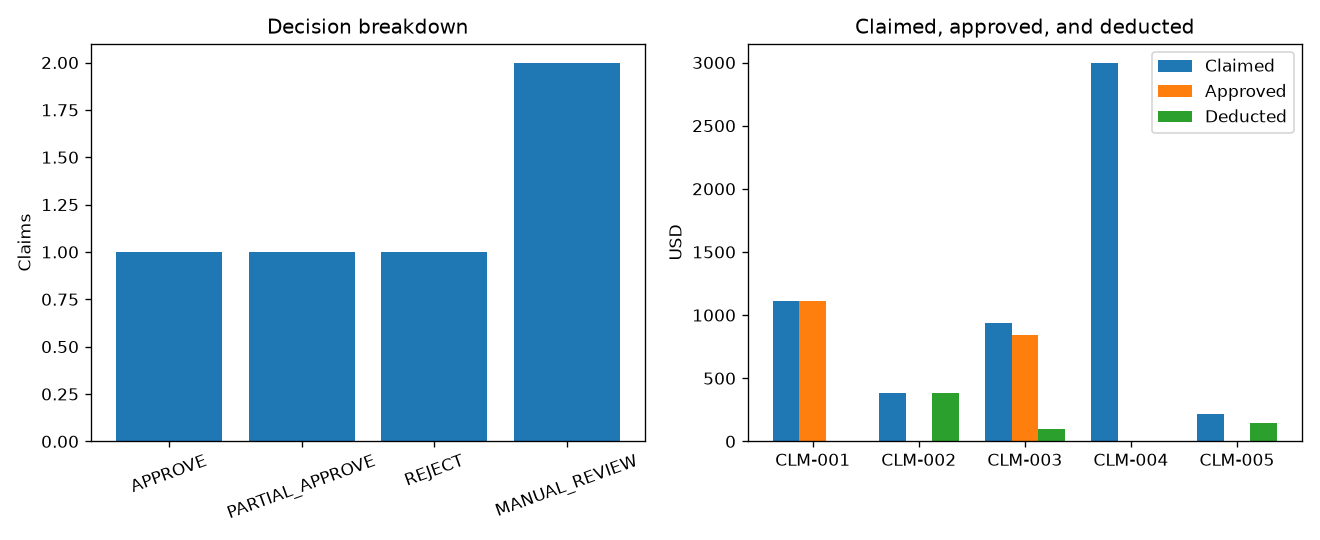

In [4]:
summary = render_dashboard(results, claims, "UI SS_1.png")
print(format_summary(summary))

from IPython.display import Image, display

display(Image(filename="UI SS_1.png"))


In [5]:
print(results_json(results))


[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-AIR-01",
      "POL-RCT-01",
      "POL-APR-02"
    ],
    "confidence": 0.95,
    "explanation": "Round-trip economy airfare is economy airfare. Hotel, 2 nights @ $180 is within $200.0/night cap. Meals, 3 days @ ~$60/day is within $75.0/day cap. Conference registration is eligible. Reimbursable total $1110.00 is in manager approval tier.",
    "tools_used": [
      "check_receipt_compliance",
      "calculate_category_limits",
      "check_timeliness_and_approval_threshold",
      "policy_lookup"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-02"
    ],
    "confidence": 0.95,
    "explanation": "Hotel spa package ($300